## Deep Learning: Deep Learning for Pneumonia Detection

### Problem Description
Pneumonia is a severe lung effection that causes inflamation within the lungs and may even lead to death if not detected on time. Traditionally, diagnosis required getting a chest X-ray, getting the results sent to a professional, and wait on the professional to diagnose the image. In this project, the goal is to apply what I've learned in "Introduction to Deep Learning" to create a develop a model to detect pneumonia from chest X-ray images. By learning from image data, different models will be trained and compared/contrasted. This automated approach has the potential to help assist medical professional, improve the industry, and ultimately, save lives. 

### Data Explaination
The data used for this project comes from the "Chest X-Ray Images (Pneumonia)" dataset on Kaggle. The dataset contains 5,863 chest X-ray images in total divided into a train dataset, validation dataset, and test dataset all with labeled images. The data comes from pediatric patients from Guangzhou Women and Children's Medical Center in Guangzhou. All of the images are in good condition; they were inspected for quality and all the images of low quality were removed. 

In [1]:
# Libraries
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img, img_to_array

import random
from glob import glob

base_dir = 'chest_xray'
train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'val')
test_dir = os.path.join(base_dir, 'test')

IMG_SIZE = (128, 128)
BATCH_SIZE = 32

### Exploratory Data Analysis

In [2]:
positive_img = load_img(os.path.join(base_dir, 'Positive_Example.jpeg'), target_size=IMG_SIZE)
normal_img = load_img(os.path.join(base_dir, 'Normal_Example.jpeg'), target_size=IMG_SIZE)
positive_array = img_to_array(positive_img) / 255.0
normal_array = img_to_array(normal_img) / 255.0

print("Image Shapes:")
print(positive_array.shape)
print(normal_array.shape)

print("Image mins:", positive_array.min())
print("Image maxes:", positive_array.max())

Image Shapes:
(128, 128, 3)
(128, 128, 3)
Image mins: 0.0
Image maxes: 1.0


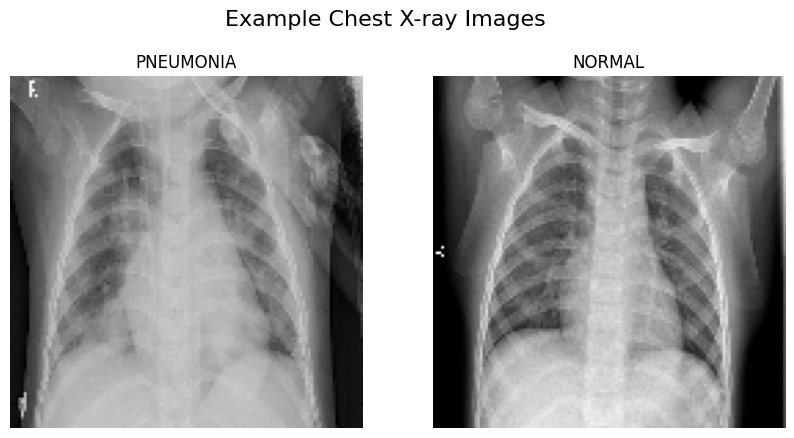

In [3]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(positive_array)
plt.title("PNEUMONIA")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(normal_array)
plt.title("NORMAL")
plt.axis('off')

plt.suptitle("Example Chest X-ray Images", fontsize=16)
plt.show()

In [4]:
# Data Generators
train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

print("Class Indices:", train_generator.class_indices)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Class Indices: {'NORMAL': 0, 'PNEUMONIA': 1}


### Procedure
The data has already been split and loaded into the dataset. To develop and evaluate a deep learning model for pneumonia detection from the X ray images, three different convolutional neural network, CNN, models were trained. Model 1 served as a baseline model consisting of a single convolutional layer with 8 filters followed by a max pooling layer, flattening, and a dense output layer with a sigmoid activation function. Model 1 was trained for 5 epochs using the Adam optimzer and binary cross entropy loss. Model 2 introduced a second convolutional layer, but only had 4 filters convolutional layers and was trained for 10 epochs. Model 3, also set to be the final model, increased the filters to 16, with 2 max pooling layers, added two dropout layers set at 25%, and was trained for 10 epochs too. The idea behind this process was to create a somewhat simple model to serve as a baseline, then a second model with different parameters (some expected to decrease accuracy and some expected to increase accuracy) to see how they affected the model, and a third model to be the most complex. This is to not only complete the project objective, but also increase my understanding about how parameters affect neural networks. 

In [5]:
# Model 1
model1 = Sequential([
    Conv2D(8, (3, 3), activation='relu', input_shape=(128, 128, 3)),
    MaxPooling2D(2, 2),
    Flatten(),
    Dense(1, activation='sigmoid')
])

model1.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("Model 1")
history1 = model1.fit(train_generator, epochs=5, validation_data=val_generator)

Model 1


C:\Users\Rbjor\Downloads\New folder\envs\tf_env\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
C:\Users\Rbjor\Downloads\New folder\envs\tf_env\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 36s 219ms/step - accuracy: 0.8254 - loss: 0.3982 - val_accuracy: 0.6875 - val_loss: 0.5268
Epoch 2/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 35s 215ms/step - accuracy: 0.9570 - loss: 0.1215 - val_accuracy: 0.8750 - val_loss: 0.2599
Epoch 3/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 35s 213ms/step - accuracy: 0.9557 - loss: 0.1144 - val_accuracy: 0.8125 - val_loss: 0.3430
Epoch 4/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 35s 214ms/step - accuracy: 0.9758 - loss: 0.0687 - val_accuracy: 0.9375 - val_loss: 0.1966
Epoch 5/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 35s 214ms/step - accuracy: 0.9770 - loss: 0.0654 - val_accuracy: 0.6875 - val_loss: 0.4782


In [6]:
# Model 2
model2 = Sequential([
    Conv2D(4, (3, 3), activation='relu', input_shape=(128, 128, 3)),
    MaxPooling2D(2, 2),
    Conv2D(4, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Flatten(),
    Dense(1, activation='sigmoid')
])

model2.compile(optimizer=Adam(learning_rate=0.001),
               loss='binary_crossentropy',
               metrics=['accuracy'])

print("Model 2")
history2 = model2.fit(train_generator, epochs=10, validation_data=val_generator)

Model 2
Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 36s 215ms/step - accuracy: 0.7780 - loss: 0.4978 - val_accuracy: 0.6250 - val_loss: 0.7843
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 35s 214ms/step - accuracy: 0.9425 - loss: 0.1554 - val_accuracy: 0.6250 - val_loss: 0.5365
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 35s 215ms/step - accuracy: 0.9513 - loss: 0.1285 - val_accuracy: 0.6250 - val_loss: 0.4669
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 35s 215ms/step - accuracy: 0.9614 - loss: 0.1064 - val_accuracy: 0.9375 - val_loss: 0.1538
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 35s 213ms/step - accuracy: 0.9633 - loss: 0.0962 - val_accuracy: 0.7500 - val_loss: 0.4096
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 35s 213ms/step - accuracy: 0.9595 - loss: 0.1025 - val_accuracy: 0.6875 - val_loss: 0.5410
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 35s 212ms/step - accuracy: 0.9649 - loss: 0.0947 - val_accuracy: 0.8750 - val_loss: 0.2684
Epoch 8/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 35s 214ms/step - accuracy: 0.9657 -

In [7]:
# Model 3
model3 = Sequential([
    Conv2D(16, (3, 3), activation='relu', input_shape=(128, 128, 3)),
    MaxPooling2D(2, 2),
    Dropout(0.25),
    Conv2D(16, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Dropout(0.25),
    Flatten(),
    Dense(1, activation='sigmoid')
])

model3.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

print("Final Model (Model 3)")
history3 = model3.fit(train_generator, epochs=10, validation_data=val_generator)

Final Model (Model 3)
Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 37s 221ms/step - accuracy: 0.7280 - loss: 0.5452 - val_accuracy: 0.8750 - val_loss: 0.3821
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 36s 222ms/step - accuracy: 0.9384 - loss: 0.1624 - val_accuracy: 0.7500 - val_loss: 0.4696
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 41s 249ms/step - accuracy: 0.9477 - loss: 0.1297 - val_accuracy: 0.7500 - val_loss: 0.3687
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 47s 290ms/step - accuracy: 0.9591 - loss: 0.1121 - val_accuracy: 0.6875 - val_loss: 0.6298
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 47s 287ms/step - accuracy: 0.9630 - loss: 0.1034 - val_accuracy: 0.9375 - val_loss: 0.2215
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 47s 289ms/step - accuracy: 0.9683 - loss: 0.0897 - val_accuracy: 0.8750 - val_loss: 0.2340
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 554s 3s/step - accuracy: 0.9736 - loss: 0.0777 - val_accuracy: 0.7500 - val_loss: 0.3696
Epoch 8/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 30s 184ms/step - accura

In [8]:
# Evaluation
test_loss, test_acc = model3.evaluate(test_generator)
print("Test Accuracy", test_acc)
print("Test Loss", test_loss)

pred_probs = model3.predict(test_generator)
pred_labels = (pred_probs > 0.5).astype(int).flatten()
true_labels = test_generator.classes

print(classification_report(true_labels, pred_labels, target_names=['NORMAL', 'PNEUMONIA']))

cm = confusion_matrix(true_labels, pred_labels)

20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 490ms/step - accuracy: 0.6280 - loss: 1.2814
Test Accuracy 0.7868589758872986
Test Loss 0.7542241215705872
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 118ms/step
              precision    recall  f1-score   support

      NORMAL       0.96      0.45      0.61       234
   PNEUMONIA       0.75      0.99      0.85       390

    accuracy                           0.79       624
   macro avg       0.86      0.72      0.73       624
weighted avg       0.83      0.79      0.76       624



## Results
Three convolutional neural networks were trained to classify the chest X rays as either NORMAL or PNEUMONIA. Model 1 was a neural network with a single convolutional layer with 8 filters trained for 5 epochs and served as the baseline model. This baseline model achieved a training accuracy of 97.7% but the validation accuracy went from 93.75% in epoch 4 down to 68.75% on epoch 5 which suggests overfitting. Model 2 added another convolutional layer but used half the amount of filters per convolutional layer than the first and was this time trained for 10 epochs. Training performance increased significantly from 62.5% up to 93.75 but the validation accuracy scores also suffered from overfitting. Lastly, model 3 was the most complex model with 2 convolutional layers each with 16 filters and a dropout of 25% to help deal with overfitting and the model was trained over 10 epochs. This model reach the same high test accuracy as model 1 of 97.7%, and a much higher validation accuracy of 81.25%. Overall, model 3 was the most consistent and the best performing model. 

### Conclusion
This project successfuly developed deep learning model to detect pneumonia from chest X-ray images. Model 1 and model 2 both had good test accuracy, but had poor performance on the validation data. This suggests that the models were overfitting to the data. Model 3 on the other hand also performed really well on the test data, and performed relatively well on the validation data. Part of the reasoning behind this is the dropout layer which dropped neurons form the network to help the network generalize better. 

Despite the project's success, there are definitely a lot of changes that can be made going forward in order to create better models and derive better insights. Potential changes include different models and architectures such as using transfer learning in order to get some of the benefits from previously created robust models. Also, parameter changes like increasing the drop out percentage and adding more epochs would help give me the model more time to learn and reduce overfitting. In real world scenarios, this type of model is already revolutionizing the medical industry by helping people get diagnosed more quickly, decreasing the costs of diagnoses, and ultimately saving lives. Especially with lethal diseases where time is of the most importance, machine learning can help make processes so much quicker. Overall, this was a fun project, and I look forward to creating similar models in the future. 

### References
Mooney, P. T. (2018). Chest X-Ray Images (Pneumonia) [Data set]. Kaggle. https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia

Scikit-learn developers. (2023). Scikit-learn: Machine learning in Python. https://scikit-learn.org/stable/index.html

TensorFlow Developers. (2024). TensorFlow API documentation. https://www.tensorflow.org/api_docs